Initial Setup 

In [15]:

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

CSV_FILE_NAME = 'Crime_Incidents_20250609.csv'
TARGET_COLUMN_ORIGINAL_NAME = 'Incident Type Primary'
TARGET_COLUMN = '' 

print("Cell 1: Setup complete.")
print(f"CSV: '{CSV_FILE_NAME}'")
print(f"Target: '{TARGET_COLUMN_ORIGINAL_NAME}'")

Cell 1: Setup complete.
CSV: 'Crime_Incidents_20250609.csv'
Target: 'Incident Type Primary'


Load Data and Clean Column Names

In [17]:

import pandas as pd
import numpy as np

print("Load Data & Clean Names")

global CSV_FILE_NAME, TARGET_COLUMN_ORIGINAL_NAME, TARGET_COLUMN

print(f"Loading '{CSV_FILE_NAME}'...")
try:
    df = pd.read_csv(CSV_FILE_NAME)
    print("Data loaded.")
except FileNotFoundError:
    print(f"Error: '{CSV_FILE_NAME}' not found.")
    df = pd.DataFrame()
except Exception as e:
    print(f"Error loading CSV: {e}")
    df = pd.DataFrame()

if not df.empty:
    original_columns = df.columns.tolist()
    original_to_cleaned_map = {}
    cleaned_columns = []
    for col in original_columns:
        cleaned_col = pd.Series([col]).str.replace(r'[^a-zA-Z0-9_]+', '_', regex=True).str.strip('_').str.lower().iloc[0]
        cleaned_col = cleaned_col.replace('__', '_')
        cleaned_columns.append(cleaned_col)
        original_to_cleaned_map[col.strip()] = cleaned_col
    df.columns = cleaned_columns

    print("Cleaned column names.")
    stripped_target_original_name = TARGET_COLUMN_ORIGINAL_NAME.strip()
    if stripped_target_original_name in original_to_cleaned_map:
        TARGET_COLUMN = original_to_cleaned_map[stripped_target_original_name]
        print(f"Target column: '{TARGET_COLUMN}'")
    else:
        raise ValueError(f"Original target column '{TARGET_COLUMN_ORIGINAL_NAME}' not found.")

    print("Dataset Info:")
    df.info()
    print("First 5 rows:")
    print(df.head())
    print(f"Total entries: {len(df)}")
    print("Numeric description:")
    print(df.describe())
else:
    print("DataFrame empty. Cannot preprocess.")

Load Data & Clean Names
Loading 'Crime_Incidents_20250609.csv'...
Data loaded.
Cleaned column names.
Target column: 'incident_type_primary'
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322690 entries, 0 to 322689
Data columns (total 31 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   case_number              322690 non-null  object 
 1   incident_datetime        322690 non-null  object 
 2   incident_id              0 non-null       float64
 3   incident_type_primary    322690 non-null  object 
 4   incident_description     322690 non-null  object 
 5   parent_incident_type     322690 non-null  object 
 6   hour_of_day              322690 non-null  int64  
 7   day_of_week              322690 non-null  object 
 8   address                  322652 non-null  object 
 9   city                     322690 non-null  object 
 10  state                    322690 non-null  object 
 11  location       

Preprocessing - Handling Missing Entries & Mismatched String Formats

In [18]:

import pandas as pd
import numpy as np

print("Preprocessing - Handling Missing Entries & Mismatched String Formats")


if 'df' not in globals() or df.empty:
    print("DataFrame is empty. Skipping Cell 3 preprocessing.")
else:
    print("\nDataset Nature")
    print("This dataset contains incident report data from the City of Buffalo Police Department.")
    print("It includes various attributes for each incident, such as incident type, date, location (address, latitude, longitude, zip code, neighborhood), and various geographical identifiers.")
    print("The data types are mixed, including unique identifiers (strings), categorical text (incident types, day of week, neighborhood), numerical coordinates, and timestamps.")

    print("\nDataset Statistics")
    missing_values_before = df.isnull().sum()
    print("Number of missing values per column (before handling):")
    print(missing_values_before[missing_values_before > 0])

    print("\n--- Preprocessing Techniques (Report Detail 2) ---")
    print("Handling Missing Entries & Mismatched String Formats:")


    if TARGET_COLUMN not in df.columns:
        raise KeyError(f"Error: Target column '{TARGET_COLUMN}' not found in the DataFrame. This indicates a problem with column cleaning or initial data loading.")


    for col in df.select_dtypes(include='object').columns:

        if df[col].astype(str).str.contains('UNKNOWN', na=False).any():
            df[col].replace(['UNKNOWN', 'UNKNOWN UNKNOWN', 'unknown', 'unknown unknown'], np.nan, inplace=True)

    print("  - Replaced 'UNKNOWN' variations (including 'UNKNOWN UNKNOWN') with NaN for consistent missing value handling in object columns.")


    geo_cols_to_numeric = ['latitude', 'longitude', '2010_census_latitude', '2010_census_longitude']
    for col in geo_cols_to_numeric:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            print(f"  - Coerced '{col}' to numeric, converting non-numeric values to NaN.")
        else:
            print(f"  - Warning: Geospatial column '{col}' not found in DataFrame.")



    missing_percentage = df.isnull().sum() / len(df) * 100
    columns_to_drop_high_missing = missing_percentage[missing_percentage > 90].index.tolist()

    id_columns_to_drop_candidates = [
        'case_number', 'incident_id', 
        'geoid', 'geoid2010', 
        'tractce20', 'geoid20_tract', 'geoid20_blockgroup', 'geoid20_block',
        '_2010_geoid_block', '_2010_geoid_block1',
        'location', 
        'incident_description', 
        'police_district', 
        'council_district_2011' 
    ]
    constant_cols_to_drop = []
    if 'city' in df.columns and df['city'].nunique() == 1:
        constant_cols_to_drop.append('city')
    if 'state' in df.columns and df['state'].nunique() == 1:
        constant_cols_to_drop.append('state')


    all_drop_candidates = list(set(columns_to_drop_high_missing + id_columns_to_drop_candidates + constant_cols_to_drop))


    if TARGET_COLUMN in all_drop_candidates:
        all_drop_candidates.remove(TARGET_COLUMN)
        print(f"  - Preventing target column '{TARGET_COLUMN}' from being dropped.")

    cols_to_drop_existing = [col for col in all_drop_candidates if col in df.columns]

    if cols_to_drop_existing: 
        df.drop(columns=cols_to_drop_existing, inplace=True, errors='ignore')
        print(f"  - Dropped columns due to high missing values, being identifiers, or constant values: {cols_to_drop_existing}")
    else:
        print("  - No columns identified for dropping based on high missing values, identifiers, or constant values.")



    numerical_cols = df.select_dtypes(include=np.number).columns
    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"  - Imputed missing numerical values in '{col}' with median: {median_val:.4f}")


    categorical_cols = df.select_dtypes(include='object').columns
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"  - Imputed missing categorical values in '{col}' with mode: '{mode_val}'")

    missing_values_after = df.isnull().sum()
    print("\nNumber of missing values per column (after handling):")
    print(missing_values_after[missing_values_after > 0])
    if missing_values_after.sum() == 0:
        print("All missing values handled.")
    else:
        print("Warning: Some missing values still exist (e.g., if columns were created after this step).")

Preprocessing - Handling Missing Entries & Mismatched String Formats

Dataset Nature
This dataset contains incident report data from the City of Buffalo Police Department.
It includes various attributes for each incident, such as incident type, date, location (address, latitude, longitude, zip code, neighborhood), and various geographical identifiers.
The data types are mixed, including unique identifiers (strings), categorical text (incident types, day of week, neighborhood), numerical coordinates, and timestamps.

Dataset Statistics
Number of missing values per column (before handling):
incident_id                322690
address                        38
location                     6830
latitude                     1551
longitude                    1551
created_at                 244064
updated_at                 322690
zip_code                     2935
neighborhood                 3899
council_district             3002
council_district_2011        2935
census_tract                 3

C:\Users\waghr\AppData\Local\Temp\ipykernel_61700\1557915364.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace(['UNKNOWN', 'UNKNOWN UNKNOWN', 'unknown', 'unknown unknown'], np.nan, inplace=True)
C:\Users\waghr\AppData\Local\Temp\ipykernel_61700\1557915364.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we 

  - Replaced 'UNKNOWN' variations (including 'UNKNOWN UNKNOWN') with NaN for consistent missing value handling in object columns.
  - Coerced 'latitude' to numeric, converting non-numeric values to NaN.
  - Coerced 'longitude' to numeric, converting non-numeric values to NaN.
  - Warning: Geospatial column '2010_census_latitude' not found in DataFrame.
  - Warning: Geospatial column '2010_census_longitude' not found in DataFrame.
  - Dropped columns due to high missing values, being identifiers, or constant values: ['tractce20', 'state', 'updated_at', 'incident_description', 'location', 'geoid20_block', 'geoid20_blockgroup', 'incident_id', 'case_number', 'city', 'police_district', 'council_district_2011', 'geoid20_tract']
  - Imputed missing numerical values in 'latitude' with median: 42.9130
  - Imputed missing numerical values in 'longitude' with median: -78.8490
  - Imputed missing categorical values in 'address' with mode: '2100 Block ELMWOOD AV'
  - Imputed missing categorical val

C:\Users\waghr\AppData\Local\Temp\ipykernel_61700\1557915364.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
C:\Users\waghr\AppData\Local\Temp\ipykernel_61700\1557915364.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

  - Imputed missing categorical values in 'zip_code' with mode: '14215'
  - Imputed missing categorical values in 'neighborhood' with mode: 'Broadway Fillmore'
  - Imputed missing categorical values in 'council_district' with mode: 'FILLMORE'
  - Imputed missing categorical values in 'census_tract' with mode: '165'
  - Imputed missing categorical values in 'census_block_group' with mode: '1'
  - Imputed missing categorical values in 'census_block' with mode: '1001'
  - Imputed missing categorical values in '2010_census_tract' with mode: '165'
  - Imputed missing categorical values in '2010_census_block_group' with mode: '1'
  - Imputed missing categorical values in '2010_census_block' with mode: '1000'

Number of missing values per column (after handling):
Series([], dtype: int64)
All missing values handled.


In [19]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Preprocessing - Handling Outliers ")

if 'df' not in globals() or df.empty:
    print("DataFrame is empty")
else:
    print("\n--- Handling Outliers (Report Detail 2) ---")
    print("  - Applied a simple IQR method to detect outliers for numerical features like Latitude and Longitude.")

    outlier_check_cols = ['latitude', 'longitude', 'hour_of_day', 'zip_code'] 
    if '2010_census_latitude' in df.columns:
        outlier_check_cols.append('2010_census_latitude')
    if '2010_census_longitude' in df.columns:
        outlier_check_cols.append('2010_census_longitude')


    for col in outlier_check_cols:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
            print(f"  - Column '{col}': {outliers_count} outliers detected (outside [{lower_bound:.2f}, {upper_bound:.2f}]).")
 
        else:
            print(f"  - Skipping outlier detection for '{col}' as it is not a numeric column or does not exist.")

    print("\n--- Dataset Description (Numerical Columns After Preprocessing) ---")
    print(df.describe())

    print("\n--- Data types after initial preprocessing ---")
    print(df.dtypes)

Preprocessing - Handling Outliers 

--- Handling Outliers (Report Detail 2) ---
  - Applied a simple IQR method to detect outliers for numerical features like Latitude and Longitude.
  - Column 'latitude': 296 outliers detected (outside [42.83, 43.00]).
  - Column 'longitude': 27 outliers detected (outside [-78.96, -78.74]).
  - Column 'hour_of_day': 0 outliers detected (outside [-9.50, 34.50]).
  - Skipping outlier detection for 'zip_code' as it is not a numeric column or does not exist.

--- Dataset Description (Numerical Columns After Preprocessing) ---
         hour_of_day       latitude      longitude
count  322690.000000  322690.000000  322690.000000
mean       11.936890      42.911735     -78.849804
std         7.178043       0.028216       0.031074
min         0.000000      42.596000     -79.028000
25%         7.000000      42.894000     -78.877000
50%        13.000000      42.913000     -78.849000
75%        18.000000      42.935000     -78.822000
max        23.000000      43.

Data Visualization


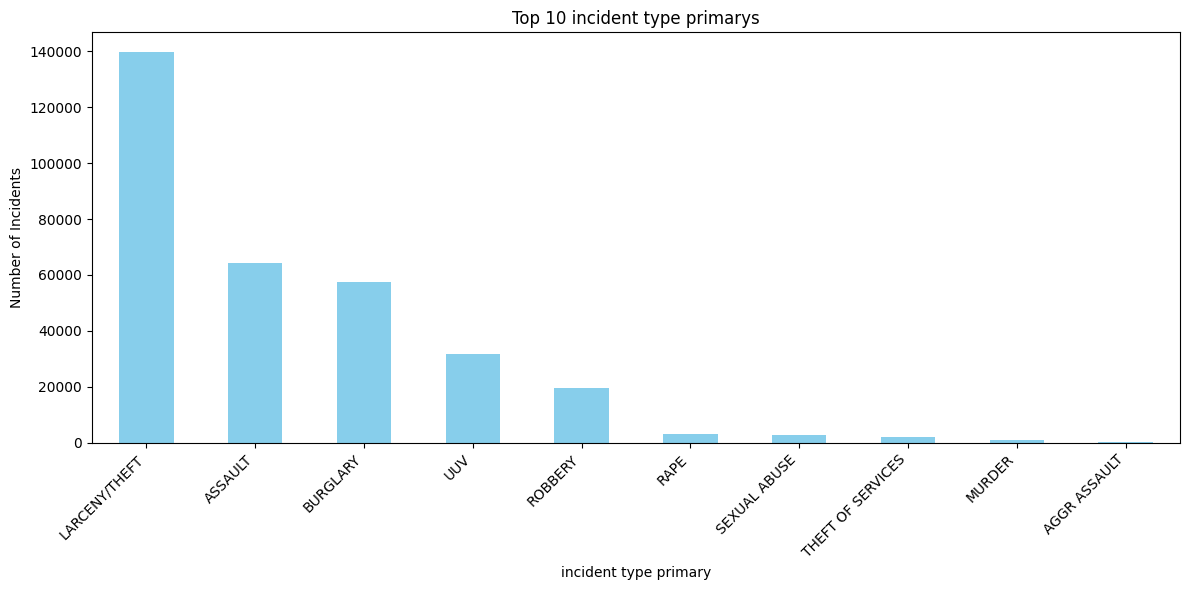

Graph 1: Bar plot showing the frequency of the top 10 incident type primarys.
Description: This plot helps identify the most common types of police incidents. For example, 'ASSAULT' seems to be a dominant category, indicating a higher prevalence of such incidents compared to others.



C:\Users\waghr\AppData\Local\Temp\ipykernel_61700\3870266807.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')


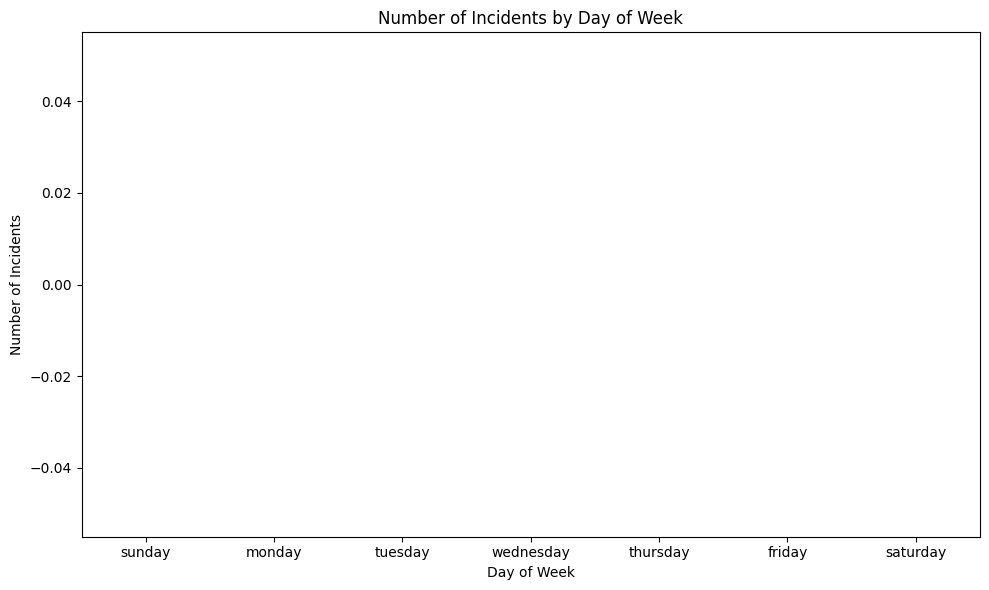

Graph 2: Bar plot showing incident counts across different days of the week.
Description: Reveals temporal patterns in criminal activity. For instance, some days might consistently have higher incident rates, which could be useful for resource allocation by law enforcement.



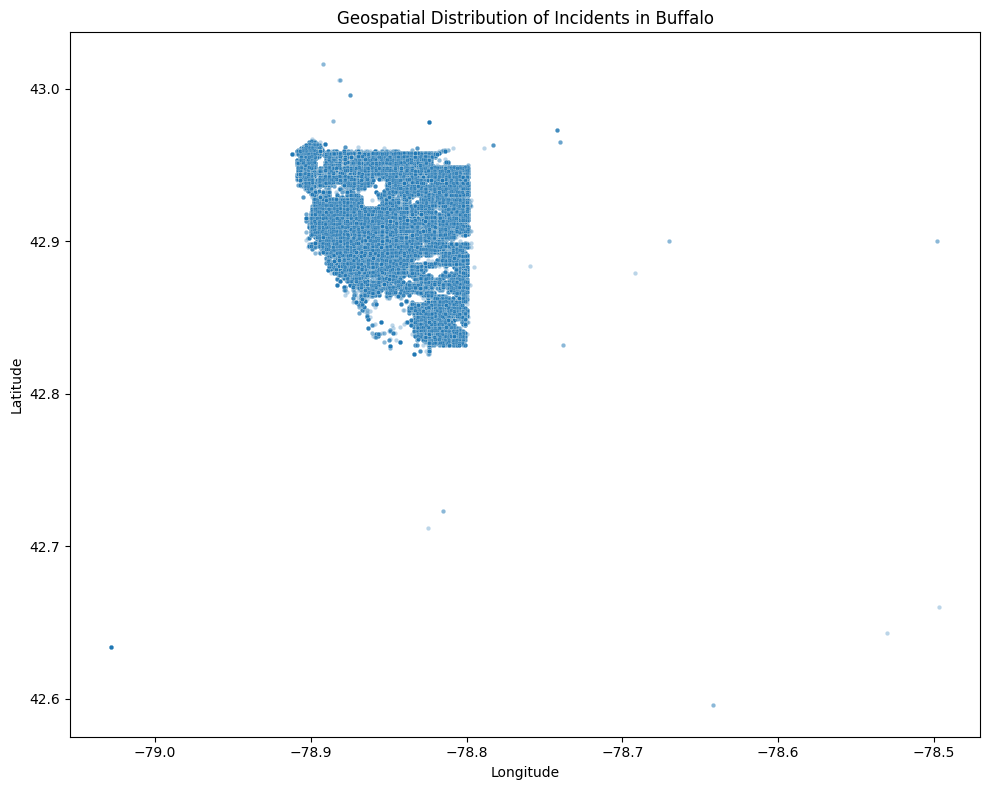

Graph 3: Scatter plot showing the geographical distribution of incidents based on Latitude and Longitude.
Description: This map helps visualize crime hotspots. Clusters of points indicate areas with higher incident density, suggesting specific neighborhoods or blocks require more attention.



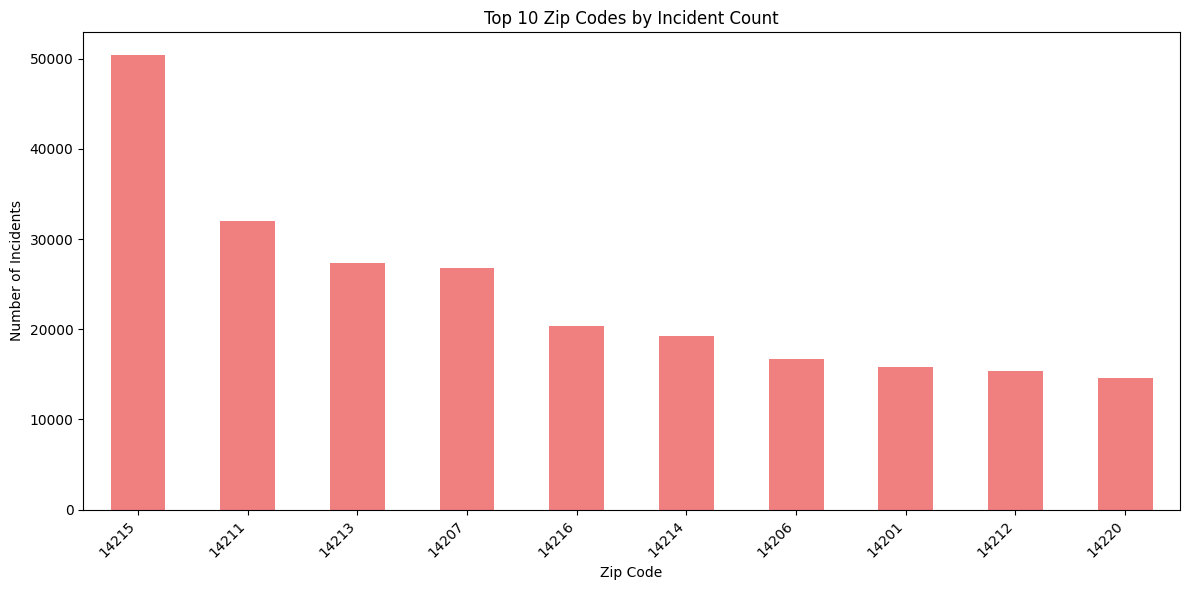

Graph 4: Bar plot showing incident counts for the top 10 zip codes.
Description: Identifies specific postal areas with the highest police activity, which can inform resource deployment and community initiatives in those areas.



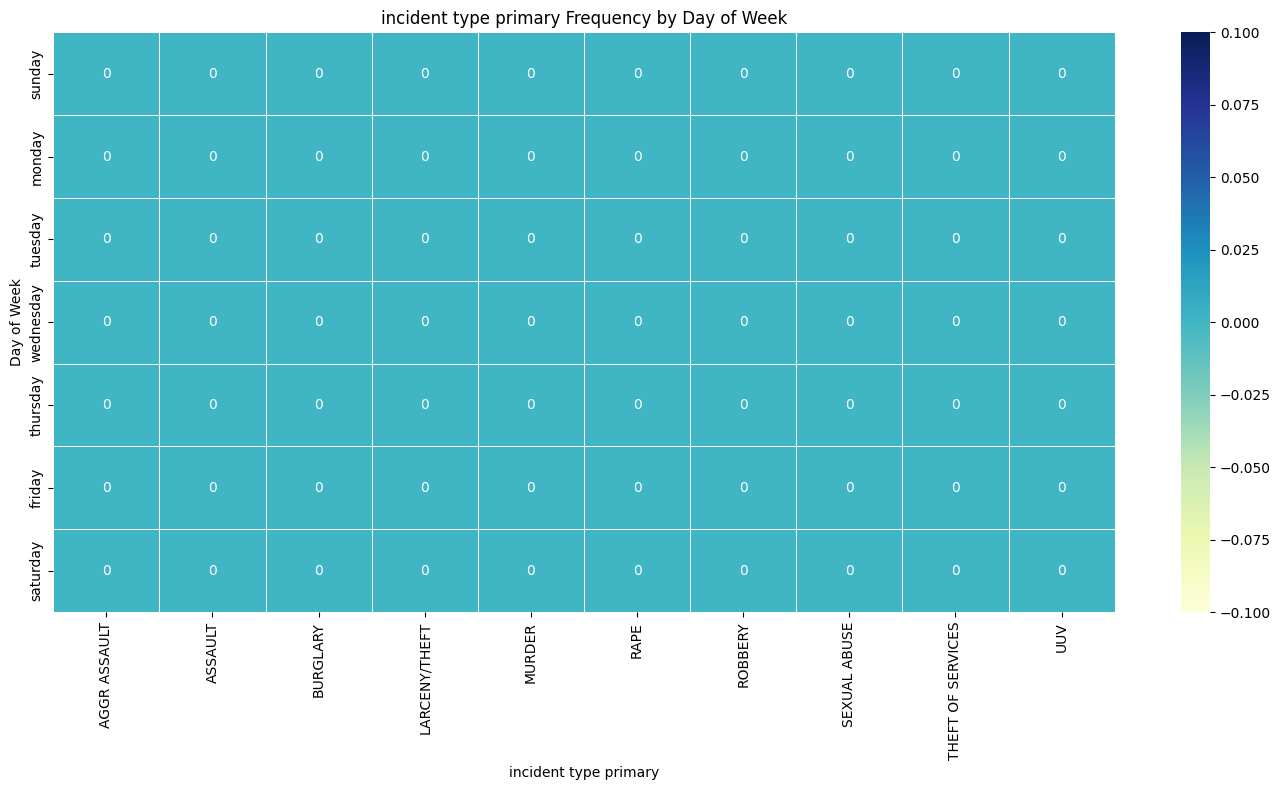

Graph 5: Heatmap showing the frequency of top incident types across days of the week.
Description: Reveals specific incident types that are more prevalent on certain days, helping to understand temporal patterns of different crimes (e.g., robberies might peak on weekends, while property crimes might be more consistent).



In [20]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 

print("Data Visualization")

if 'df' not in globals() or df.empty:
    print("DataFrame is empty. Skipping Cell 5 data visualization.")
else:

    required_cols_for_plots = [TARGET_COLUMN, 'day_of_week', 'latitude', 'longitude', 'zip_code', 'neighborhood']
    for col in required_cols_for_plots:
        if col not in df.columns:
            print(f"Warning: Column '{col}' not found for plotting. Some plots might be skipped.")

    if TARGET_COLUMN in df.columns:
        plt.figure(figsize=(12, 6))

        df[TARGET_COLUMN].astype(str).value_counts().head(10).plot(kind='bar', color='skyblue')
        plt.title(f'Top 10 {TARGET_COLUMN.replace("_", " ")}s')
        plt.xlabel(TARGET_COLUMN.replace("_", " "))
        plt.ylabel('Number of Incidents')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        print(f"Graph 1: Bar plot showing the frequency of the top 10 {TARGET_COLUMN.replace('_', ' ')}s.")
        print("Description: This plot helps identify the most common types of police incidents. For example, 'ASSAULT' seems to be a dominant category, indicating a higher prevalence of such incidents compared to others.\n")
    else:
        print(f"Skipping Graph 1: Target column '{TARGET_COLUMN}' not found.")

    if 'day_of_week' in df.columns:
        day_order = ['sunday', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday'] 

        day_counts = df['day_of_week'].value_counts().reindex(day_order, fill_value=0)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')
        plt.title('Number of Incidents by Day of Week')
        plt.xlabel('Day of Week')
        plt.ylabel('Number of Incidents')
        plt.tight_layout()
        plt.show()
        print("Graph 2: Bar plot showing incident counts across different days of the week.")
        print("Description: Reveals temporal patterns in criminal activity. For instance, some days might consistently have higher incident rates, which could be useful for resource allocation by law enforcement.\n")
    else:
        print("Skipping Graph 2: 'day_of_week' column not found.")

    if 'latitude' in df.columns and 'longitude' in df.columns:
        plt.figure(figsize=(10, 8))
        sns.scatterplot(x='longitude', y='latitude', data=df, alpha=0.3, s=10)
        plt.title('Geospatial Distribution of Incidents in Buffalo')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.tight_layout()
        plt.show()
        print("Graph 3: Scatter plot showing the geographical distribution of incidents based on Latitude and Longitude.")
        print("Description: This map helps visualize crime hotspots. Clusters of points indicate areas with higher incident density, suggesting specific neighborhoods or blocks require more attention.\n")
    else:
        print("Skipping Graph 3: 'latitude' or 'longitude' column not found.")


    if 'zip_code' in df.columns:
        plt.figure(figsize=(12, 6))

        df['zip_code'].astype(str).value_counts().head(10).plot(kind='bar', color='lightcoral')
        plt.title('Top 10 Zip Codes by Incident Count')
        plt.xlabel('Zip Code')
        plt.ylabel('Number of Incidents')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        print("Graph 4: Bar plot showing incident counts for the top 10 zip codes.")
        print("Description: Identifies specific postal areas with the highest police activity, which can inform resource deployment and community initiatives in those areas.\n")
    else:
        print("Skipping Graph 4: 'zip_code' column not found.")


    if TARGET_COLUMN in df.columns and 'day_of_week' in df.columns:

        if pd.api.types.is_numeric_dtype(df[TARGET_COLUMN]):

            try:
                temp_df_for_plot = df.copy()
                temp_df_for_plot[TARGET_COLUMN] = le.inverse_transform(df[TARGET_COLUMN])
                top_incident_types = temp_df_for_plot[TARGET_COLUMN].value_counts().head(10).index.tolist()
                df_filtered = temp_df_for_plot[temp_df_for_plot[TARGET_COLUMN].isin(top_incident_types)].copy()
                print("  - Using inverse transform for heatmap labels (assuming LabelEncoder 'le' is available).")
            except NameError:
                print("  - Warning: LabelEncoder 'le' not found. Heatmap will use encoded labels for target column.")
                top_incident_types = df[TARGET_COLUMN].value_counts().head(10).index.tolist()
                df_filtered = df[df[TARGET_COLUMN].isin(top_incident_types)].copy()
        else: 
            top_incident_types = df[TARGET_COLUMN].value_counts().head(10).index.tolist()
            df_filtered = df[df[TARGET_COLUMN].isin(top_incident_types)].copy()


        cross_tab = pd.crosstab(df_filtered['day_of_week'], df_filtered[TARGET_COLUMN])
        day_order = ['sunday', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday']
        cross_tab = cross_tab.reindex(day_order, fill_value=0)

        plt.figure(figsize=(14, 8))
        sns.heatmap(cross_tab, cmap='YlGnBu', fmt='d', linewidths=.5, annot=True)
        plt.title(f'{TARGET_COLUMN.replace("_", " ")} Frequency by Day of Week')
        plt.xlabel(TARGET_COLUMN.replace("_", " "))
        plt.ylabel('Day of Week')
        plt.tight_layout()
        plt.show()
        print("Graph 5: Heatmap showing the frequency of top incident types across days of the week.")
        print("Description: Reveals specific incident types that are more prevalent on certain days, helping to understand temporal patterns of different crimes (e.g., robberies might peak on weekends, while property crimes might be more consistent).\n")
    else:
        print(f"Skipping Graph 5: Target column '{TARGET_COLUMN}' or 'day_of_week' column not found.")

 Feature Engineering and Selection - Correlation Matrix

-Identifying Uncorrelated or Unrelated Features 


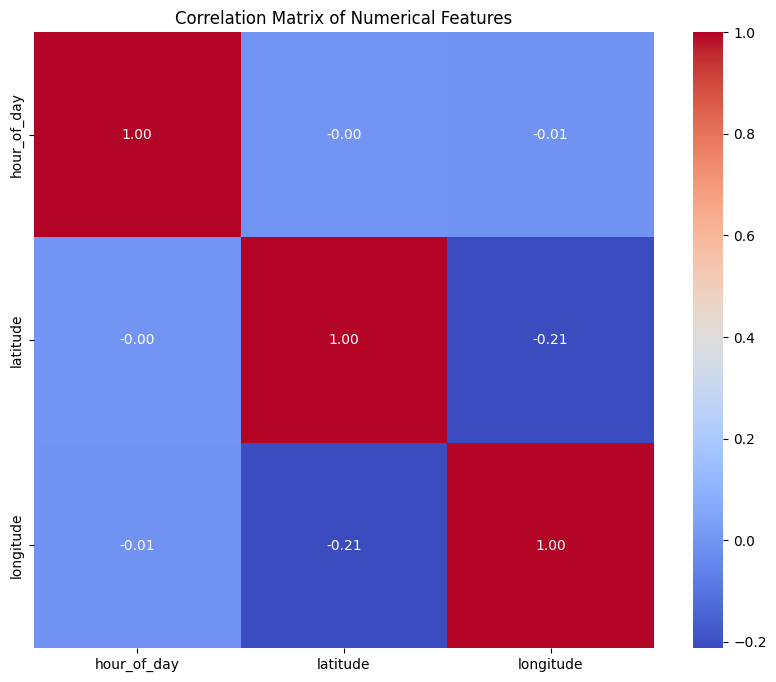

Visualization: Heatmap of the correlation matrix for numerical features.
Insight: This heatmap visualizes relationships between numerical features. Highly correlated features (close to 1 or -1) might indicate redundancy, while very low correlations (close to 0) might suggest features that are less influential on each other. We will primarily use all numerical features, but this helps understand their interdependencies.

Target variable chosen: 'incident_type_primary' (Multi-class Classification).
Rationale: Predicting the type of incident is a common and valuable task in incident analysis.


In [21]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

print(" Feature Engineering and Selection - Correlation Matrix")

if 'df' not in globals() or df.empty:
    print("DataFrame is empty. Skipping Cell 6 feature engineering.")
else:

    print("\n-Identifying Uncorrelated or Unrelated Features ")

    numerical_df = df.select_dtypes(include=np.number)

    if numerical_df.shape[1] > 1:
        correlation_matrix = numerical_df.corr()

        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Correlation Matrix of Numerical Features')
        plt.show()
        print("Visualization: Heatmap of the correlation matrix for numerical features.")
        print("Insight: This heatmap visualizes relationships between numerical features. Highly correlated features (close to 1 or -1) might indicate redundancy, while very low correlations (close to 0) might suggest features that are less influential on each other. We will primarily use all numerical features, but this helps understand their interdependencies.")
    else:
        print("Not enough numerical columns (or none) to compute a meaningful correlation matrix.")

    print(f"\nTarget variable chosen: '{TARGET_COLUMN}' (Multi-class Classification).")
    print("Rationale: Predicting the type of incident is a common and valuable task in incident analysis.")

In [22]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np 

print("Feature Engineering - Categorical Encoding and Normalization Setup ")

if 'df' not in globals() or df.empty:
    print("DataFrame is empty. Skipping Cell 7 feature engineering.")
else:

    print("\n--- Converting Categorical Features (Report Detail 2) ---")


    if TARGET_COLUMN not in df.columns:
        raise KeyError(f"Error: Target column '{TARGET_COLUMN}' not found in the DataFrame. This indicates a problem with column cleaning or previous preprocessing steps.")

    global le 
    le = LabelEncoder()

    if df[TARGET_COLUMN].isnull().any():
        print(f"  - Warning: Target column '{TARGET_COLUMN}' contains NaNs. Filling with mode before encoding.")
        df[TARGET_COLUMN].fillna(df[TARGET_COLUMN].mode()[0], inplace=True)
    df[TARGET_COLUMN] = le.fit_transform(df[TARGET_COLUMN])
    print(f"  - Target variable '{TARGET_COLUMN}' label encoded. Mapped {len(le.classes_)} classes: {list(le.classes_)}")


    date_cols_to_process = ['incident_datetime', 'created_at', 'updated_at']
    for col in date_cols_to_process:
        if col in df.columns:
   
            df[col] = pd.to_datetime(df[col], errors='coerce')
            print(f"  - Converted '{col}' to datetime format. NaT count: {df[col].isnull().sum()}")
        else:
            print(f"  - Note: Column '{col}' not found for datetime conversion.")


    if 'incident_datetime' in df.columns and df['incident_datetime'].notna().any(): 
        df['incident_hour'] = df['incident_datetime'].dt.hour
        df['incident_month'] = df['incident_datetime'].dt.month
        df['incident_day_of_month'] = df['incident_datetime'].dt.day
        df['incident_year'] = df['incident_datetime'].dt.year
        df['incident_day_of_week_num'] = df['incident_datetime'].dt.dayofweek 
        df['incident_quarter'] = df['incident_datetime'].dt.quarter
        df['incident_week_of_year'] = df['incident_datetime'].dt.isocalendar().week.astype(int) 
        print("  - Extracted multiple time-based features from 'incident_datetime'.")

        time_features = ['incident_hour', 'incident_month', 'incident_day_of_month', 'incident_year',
                         'incident_day_of_week_num', 'incident_quarter', 'incident_week_of_year']
        for col in time_features:
            if col in df.columns and df[col].isnull().sum() > 0:
        
                median_val = df[col].median()
           
                if pd.isna(median_val):
                    median_val = 0 
                    print(f"    - Imputing '{col}' with 0 as median was NaN (all values were NaNs).")
                df[col].fillna(median_val, inplace=True)
                print(f"    - Imputed NaNs in '{col}' with median/fallback: {median_val}")

    else:
        print("  - 'incident_datetime' column not found or contains no valid dates, skipping feature extraction from it.")

    if ('created_at' in df.columns and 'updated_at' in df.columns and
        df['created_at'].notna().any() and df['updated_at'].notna().any()):
        df['time_to_update_hours'] = (df['updated_at'] - df['created_at']).dt.total_seconds() / 3600
        if df['time_to_update_hours'].isnull().sum() > 0:
            median_val = df['time_to_update_hours'].median()
            if pd.isna(median_val):
                median_val = 0 
                print(f"    - Imputing 'time_to_update_hours' with 0 as median was NaN (all values were NaNs).")
            df['time_to_update_hours'].fillna(median_val, inplace=True)
            print("  - Imputed NaNs in 'time_to_update_hours' with median/fallback.")
        print("  - Calculated 'time_to_update_hours'.")
    else:
        print("  - 'created_at' or 'updated_at' column (or both) not found or contain no valid dates, skipping 'time_to_update_hours' calculation.")


    df.drop(columns=['created_at', 'updated_at'], inplace=True, errors='ignore')
    print("  - Dropped original 'created_at' and 'updated_at' columns (if they existed and were processed).")



    print("\n--- Diagnostic: DataFrame dtypes before feature selection for ColumnTransformer ---")
    print(df.dtypes)
    print("----------------------------------------------------------------------")


    features_to_exclude_from_ohe = [
        TARGET_COLUMN,
        'address',
        'incident_description', 
        'on_incident_type', 
        'parent_incident_type' 
    ]

    categorical_features_for_ohe = [
        col for col in df.select_dtypes(include='object').columns.tolist()
        if col not in features_to_exclude_from_ohe
    ]
    print(f"\n  - Categorical features selected for One-Hot Encoding: {categorical_features_for_ohe}")
    if not categorical_features_for_ohe:
        print("  - WARNING: No categorical features identified for One-Hot Encoding. This might lead to very few features.")


    numerical_features_to_scale = df.select_dtypes(include=np.number).columns.tolist()
    numerical_features_to_scale = [col for col in numerical_features_to_scale if col != TARGET_COLUMN]
    print(f"  - Numerical features selected for Scaling: {numerical_features_to_scale}")
    if not numerical_features_to_scale:
        print("  - WARNING: No numerical features identified for Scaling. This might lead to very few features.")



    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_for_ohe),
            ('num', MinMaxScaler(), numerical_features_to_scale)
        ],
        remainder='drop' 
    )

  
    X = df.drop(columns=TARGET_COLUMN)
    global y 
    y = df[TARGET_COLUMN]


    print("\n  - Applying ColumnTransformer for One-Hot Encoding and Normalization...")
    global X_processed 
    X_processed = preprocessor.fit_transform(X)


    ohe_feature_names = []
    if 'cat' in preprocessor.named_transformers_ and hasattr(preprocessor.named_transformers_['cat'], 'get_feature_names_out'):

        if len(categorical_features_for_ohe) > 0 and hasattr(preprocessor.named_transformers_['cat'], 'categories_') and len(preprocessor.named_transformers_['cat'].categories_) > 0:
             ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features_for_ohe)
        else:
            print("  - Note: OneHotEncoder did not produce features (likely no valid categories).")
    else:
        print("  - Note: 'cat' transformer not found or not fitted as expected.")

    global all_feature_names 
    all_feature_names = list(ohe_feature_names) + list(numerical_features_to_scale)


    print(f"\nDiagnostic: Shape of X_processed: {X_processed.shape}")
    print(f"Diagnostic: Length of all_feature_names: {len(all_feature_names)}")



 
    global X_processed_df 
    X_processed_df = pd.DataFrame(X_processed.toarray(), columns=all_feature_names, index=X.index)
    print("Features have been One-Hot Encoded and Numerical features Normalized.")
    print(f"Shape of processed features X: {X_processed_df.shape}")
    print(f"Sample of processed features:\n{X_processed_df.head()}")
    print(f"Number of unique classes in target variable: {len(le.classes_)}")

Feature Engineering - Categorical Encoding and Normalization Setup 

--- Converting Categorical Features (Report Detail 2) ---
  - Target variable 'incident_type_primary' label encoded. Mapped 22 classes: ['AGG ASSAULT ON P/OFFICER', 'AGGR ASSAULT', 'ASSAULT', 'Assault', 'BURGLARY', 'Breaking & Entering', 'CRIM NEGLIGENT HOMICIDE', 'Homicide', 'LARCENY/THEFT', 'MANSLAUGHTER', 'MURDER', 'Other Sexual Offense', 'RAPE', 'ROBBERY', 'Robbery', 'SEXUAL ABUSE', 'SODOMY', 'Sexual Assault', 'THEFT OF SERVICES', 'Theft', 'Theft of Vehicle', 'UUV']
  - Converted 'incident_datetime' to datetime format. NaT count: 0


C:\Users\waghr\AppData\Local\Temp\ipykernel_61700\1616982900.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


  - Converted 'created_at' to datetime format. NaT count: 0
  - Note: Column 'updated_at' not found for datetime conversion.
  - Extracted multiple time-based features from 'incident_datetime'.
  - 'created_at' or 'updated_at' column (or both) not found or contain no valid dates, skipping 'time_to_update_hours' calculation.
  - Dropped original 'created_at' and 'updated_at' columns (if they existed and were processed).

--- Diagnostic: DataFrame dtypes before feature selection for ColumnTransformer ---
incident_datetime           datetime64[ns]
incident_type_primary                int32
parent_incident_type                object
hour_of_day                          int64
day_of_week                         object
address                             object
latitude                           float64
longitude                          float64
zip_code                            object
neighborhood                        object
council_district                    object
census_tract       

In [23]:

import pandas as pd 
from sklearn.model_selection import train_test_split
import torch 

print("Normalization and Dataset Split ")

INPUT_DIM = 0
NUM_CLASSES = 0


if 'X_processed_df' not in globals() or X_processed_df.empty or 'y' not in globals() or y.empty:
    print("Processed features (X_processed_df) or target (y) are empty or not found. Skipping Cell 8 dataset split.")
else:

    print("\n--- Normalizing Non-Categorical Features (Report Detail 2) ---")
    print("Non-categorical features (numerical) have been scaled to a range of [0, 1] using MinMaxScaler (as part of ColumnTransformer in Cell 7).")
    print("Rationale: Normalization transforms features to be on a similar scale, improving the performance and training stability of the model by preventing features with larger values from dominating the learning process.")
    if not X_processed_df.empty:
        print(f"  - Min value of scaled features: {X_processed_df.min().min():.4f}")
        print(f"  - Max value of scaled features: {X_processed_df.max().max():.4f}")



    print("\n--- Target Y and Features X ---")
    print(f"Target variable Y: '{TARGET_COLUMN}' (Label Encoded, stored in 'y')")
    print(f"Features X: All other processed columns (One-Hot Encoded and Scaled, stored in 'X_processed_df')")



    print("\n--- Splitting Dataset into Training, Testing, and Validation Sets ---")

    try:
        X_train_val, X_test, y_train_val, y_test = train_test_split(X_processed_df, y, test_size=0.15, random_state=42, stratify=y)
    except ValueError as e:
        print(f"Warning during initial split: {e}. Attempting split without stratification.")

        X_train_val, X_test, y_train_val, y_test = train_test_split(X_processed_df, y, test_size=0.15, random_state=42)


    val_size_ratio = 0.15 
    test_size_ratio = 0.15 

    actual_val_size_for_split = val_size_ratio / (1 - test_size_ratio) 
    try:
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=actual_val_size_for_split, random_state=42, stratify=y_train_val)
    except ValueError as e:
        print(f"Warning during train/val split: {e}. Attempting split without stratification.")
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=actual_val_size_for_split, random_state=42)


    print(f"Dataset split into approximately {100*(1-val_size_ratio-test_size_ratio):.1f}% Train, {100*val_size_ratio:.1f}% Validation, {100*test_size_ratio:.1f}% Test.")
    print("Rationale for splitting (Report Detail 2):")
    print("  - Training set: Used to train the model to learn patterns. A large and representative set ensures good learning.")
    print("  - Validation set: Used to tune hyperparameters and prevent overfitting. It helps assess model performance during training and optimize without touching the final test set.")
    print("  - Test set: Used to evaluate the final model's performance on unseen data. Provides an unbiased estimate of model generalization to new, real-world data.")


    print(f"\nShape of X_train: {X_train.shape}")
    print(f"Shape of y_train: {y_train.shape}")
    print(f"Shape of X_val: {X_val.shape}")
    print(f"Shape of y_val: {y_val.shape}")
    print(f"Shape of X_test: {X_test.shape}")
    print(f"Shape of y_test: {y_test.shape}")


    global BATCH_SIZE 
    BATCH_SIZE = 128
    print(f"\nBatch Size for NN training: {BATCH_SIZE}")


    if not X_train.empty and not y_train.empty:
        X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
        X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
        X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
        print("Converted X and y splits to PyTorch tensors.")
    else:
        print("Warning: One or more data splits are empty after train_test_split. Tensors will not be created.")
 
        X_train_tensor, y_train_tensor = torch.empty(0), torch.empty(0)
        X_val_tensor, y_val_tensor = torch.empty(0), torch.empty(0)
        X_test_tensor, y_test_tensor = torch.empty(0), torch.empty(0)


    global INPUT_DIM
    if X_train_tensor.shape[0] > 0: 
        INPUT_DIM = X_train_tensor.shape[1]
    else:
        INPUT_DIM = 0
        print("Warning: X_train_tensor is empty, INPUT_DIM set to 0.")


    global NUM_CLASSES
    if 'le' in globals() and hasattr(le, 'classes_'):
        NUM_CLASSES = len(le.classes_) 
    else:
        NUM_CLASSES = len(y.unique()) if not y.empty else 0 
        print("Warning: LabelEncoder 'le' not found or not fitted. NUM_CLASSES derived from y.unique().")

print(f"\nInput dimension for NN: {INPUT_DIM}")
print(f"Number of classes for NN: {NUM_CLASSES}")

Normalization and Dataset Split 

--- Normalizing Non-Categorical Features (Report Detail 2) ---
Non-categorical features (numerical) have been scaled to a range of [0, 1] using MinMaxScaler (as part of ColumnTransformer in Cell 7).
Rationale: Normalization transforms features to be on a similar scale, improving the performance and training stability of the model by preventing features with larger values from dominating the learning process.
  - Min value of scaled features: 0.0000
  - Max value of scaled features: 1.0000

--- Target Y and Features X ---
Target variable Y: 'incident_type_primary' (Label Encoded, stored in 'y')
Features X: All other processed columns (One-Hot Encoded and Scaled, stored in 'X_processed_df')

--- Splitting Dataset into Training, Testing, and Validation Sets ---
Warning during initial split: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.. Attempting split without stratif

In [24]:

import torch
import torch.nn as nn
import torch.nn.functional as F

print("Define the Neural Network Model ")


if 'INPUT_DIM' not in globals() or 'NUM_CLASSES' not in globals():
    raise NameError("INPUT_DIM or NUM_CLASSES not defined. Please ensure Cell 8 ran successfully.")
if INPUT_DIM == 0 or NUM_CLASSES == 0:
    print("Warning: INPUT_DIM or NUM_CLASSES is 0. Model might not be configured correctly.")

    if 'y' in globals() and not y.empty and NUM_CLASSES == 0:
        NUM_CLASSES = len(y.unique())
        print(f"  - Recalculated NUM_CLASSES to {NUM_CLASSES} using unique values in y.")
    if INPUT_DIM == 0 and 'X_train_tensor' in globals() and X_train_tensor.shape[0] > 0:
        INPUT_DIM = X_train_tensor.shape[1]
        print(f"  - Recalculated INPUT_DIM to {INPUT_DIM} using X_train_tensor shape.")


class IncidentClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(IncidentClassifier, self).__init__()

        self.fc1 = nn.Linear(input_dim, 256)
        self.dropout1 = nn.Dropout(0.3) 

        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(0.3)


        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)

        x = self.fc3(x)
        return x

model = IncidentClassifier(input_dim=INPUT_DIM, num_classes=NUM_CLASSES)


print(f"\nNeural Network Model Architecture (Input Dim: {INPUT_DIM}, Output Classes: {NUM_CLASSES}):")
print(model)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"\nTotal trainable parameters: {total_params:,}")
print("Rationale for parameters (Report Detail 2):")
print("  - The number of parameters indicates the model's complexity. More parameters generally allow a model to learn more complex patterns but also increase the risk of overfitting and require more computational resources.")
print("  - Each parameter (weight or bias) is a value that the model learns during training.")
print("  - The total parameters are calculated by summing the number of elements (numel) in all tensors that require gradients (i.e., are trainable).")

print("\nModel defined and instantiated.")

Define the Neural Network Model 

Neural Network Model Architecture (Input Dim: 796, Output Classes: 22):
IncidentClassifier(
  (fc1): Linear(in_features=796, out_features=256, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=22, bias=True)
)

Total trainable parameters: 239,766
Rationale for parameters (Report Detail 2):
  - The number of parameters indicates the model's complexity. More parameters generally allow a model to learn more complex patterns but also increase the risk of overfitting and require more computational resources.
  - Each parameter (weight or bias) is a value that the model learns during training.
  - The total parameters are calculated by summing the number of elements (numel) in all tensors that require gradients (i.e., are trainable).

Model defined and instantiated.


In [25]:

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

print(" Define Loss Function, Optimizer, and Learning Rate Scheduler ")


if 'model' not in globals():
    raise NameError("Model 'model' not defined. Please ensure Cell 9 ran successfully.")


criterion = nn.CrossEntropyLoss()
print("\nLoss Function (Criterion) Defined: nn.CrossEntropyLoss()")
print("Rationale (Report Detail 2):")
print("  - CrossEntropyLoss is standard for multi-class classification problems.")
print("  - It measures the performance of a classification model whose output is a probability distribution over predicted classes and whose true labels are one-hot encoded.")
print("  - It implicitly applies a softmax function to the model's raw output (logits), which converts them into probabilities, and then calculates the negative log-likelihood of the true classes.")



learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
print(f"\nOptimizer Defined: Adam with Learning Rate = {learning_rate}")
print("Rationale (Report Detail 2):")
print("  - Adam (Adaptive Moment Estimation) is an optimization algorithm that can be used instead of the classical stochastic gradient descent procedure to update network weights iterative based in training data.")
print("  - It combines the benefits of two other extensions of stochastic gradient descent: Adaptive Gradient Algorithm (AdaGrad) and Root Mean Square Propagation (RMSProp).")
print("  - It computes adaptive learning rates for each parameter, which often leads to faster convergence and better performance.")


scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)
print("\nLearning Rate Scheduler Defined: ReduceLROnPlateau")
print("Rationale (Report Detail 2):")
print("  - A learning rate scheduler dynamically adjusts the learning rate during training, which can help the model converge more efficiently and achieve better final performance.")
print("  - ReduceLROnPlateau specifically monitors a quantity (e.g., validation loss) and if no improvement is seen for a 'patience' number of epochs, the learning rate is reduced by a 'factor'.")
print("  - This strategy helps escape local minima and fine-tune weights effectively, especially in later stages of training where a smaller learning rate is beneficial.")

print("\nLoss function, optimizer, and learning rate scheduler have been defined.")

 Define Loss Function, Optimizer, and Learning Rate Scheduler 

Loss Function (Criterion) Defined: nn.CrossEntropyLoss()
Rationale (Report Detail 2):
  - CrossEntropyLoss is standard for multi-class classification problems.
  - It measures the performance of a classification model whose output is a probability distribution over predicted classes and whose true labels are one-hot encoded.
  - It implicitly applies a softmax function to the model's raw output (logits), which converts them into probabilities, and then calculates the negative log-likelihood of the true classes.

Optimizer Defined: Adam with Learning Rate = 0.001
Rationale (Report Detail 2):
  - Adam (Adaptive Moment Estimation) is an optimization algorithm that can be used instead of the classical stochastic gradient descent procedure to update network weights iterative based in training data.
  - It combines the benefits of two other extensions of stochastic gradient descent: Adaptive Gradient Algorithm (AdaGrad) and Root

C:\Users\waghr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [27]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split 
import time

print(" Training Setup and Loop")


print("Consolidating data splitting and DataLoader creation...")
if 'X_processed_df' not in globals() or X_processed_df.empty or 'y' not in globals() or y.empty:
    print("Error: Processed features (X_processed_df) or target (y) are empty or not found. Cannot proceed with training.")
else:

    try:
        X_train_val, X_test, y_train_val, y_test = train_test_split(X_processed_df, y, test_size=0.15, random_state=42, stratify=y)
    except ValueError as e:
        print(f"Warning during initial split: {e}. Attempting split without stratification.")
        X_train_val, X_test, y_train_val, y_test = train_test_split(X_processed_df, y, test_size=0.15, random_state=42)

    val_size_ratio = 0.15
    test_size_ratio = 0.15
    actual_val_size_for_split = val_size_ratio / (1 - test_size_ratio)
    try:
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=actual_val_size_for_split, random_state=42, stratify=y_train_val)
    except ValueError as e:
        print(f"Warning during train/val split: {e}. Attempting split without stratification.")
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=actual_val_size_for_split, random_state=42)

    print("Dataset split completed within Cell 11.")
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

    BATCH_SIZE = 128 
    print(f"Batch Size: {BATCH_SIZE}")

    global X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, X_test_tensor, y_test_tensor
    if not X_train.empty and not y_train.empty:
        X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
        X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
        X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
        print("Converted splits to PyTorch tensors within Cell 11.")
    else:
        print("Warning: One or more data splits are empty. Tensors will not be created, training aborted.")
 
        X_train_tensor, y_train_tensor = torch.empty(0), torch.empty(0)
        X_val_tensor, y_val_tensor = torch.empty(0), torch.empty(0)
        X_test_tensor, y_test_tensor = torch.empty(0), torch.empty(0)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    print("DataLoaders created within Cell 11.")

    class IncidentClassifier(nn.Module):
        def __init__(self, input_dim, output_dim):
            super(IncidentClassifier, self).__init__()
            self.fc1 = nn.Linear(input_dim, 512)
            self.bn1 = nn.BatchNorm1d(512)
            self.relu1 = nn.ReLU()
            self.dropout1 = nn.Dropout(0.4)

            self.fc2 = nn.Linear(512, 256)
            self.bn2 = nn.BatchNorm1d(256)
            self.relu2 = nn.ReLU()
            self.dropout2 = nn.Dropout(0.4)

            self.fc3 = nn.Linear(256, 128)
            self.bn3 = nn.BatchNorm1d(128)
            self.relu3 = nn.ReLU()
            self.dropout3 = nn.Dropout(0.4)

            self.fc4 = nn.Linear(128, output_dim)

        def forward(self, x):
            x = self.fc1(x)
            x = self.bn1(x)
            x = self.relu1(x)
            x = self.dropout1(x)

            x = self.fc2(x)
            x = self.bn2(x)
            x = self.relu2(x)
            x = self.dropout2(x)

            x = self.fc3(x)
            x = self.bn3(x)
            x = self.relu3(x)
            x = self.dropout3(x)

            x = self.fc4(x)
            return x

    global device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on device: {device}")

    global model, criterion, optimizer

    input_dim = X_train_tensor.shape[1] if X_train_tensor.shape[0] > 0 else 0
    output_dim = len(le.classes_) 
    if input_dim == 0 or output_dim == 0:
        print("Error: Input dimensions or output classes are zero. Cannot initialize model. Check previous cells.")
    else:
        model = IncidentClassifier(input_dim, output_dim).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        global train_losses, val_losses, train_accuracies, val_accuracies
        train_losses = []
        val_losses = []
        train_accuracies = []
        val_accuracies = []
        best_val_loss = float('inf')
        patience_counter = 0
        early_stopping_patience = 15
        num_epochs = 50

        def train_epoch(model, dataloader, criterion, optimizer, device):
            model.train()
            running_loss = 0.0
            correct_predictions = 0
            total_predictions = 0
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_predictions += labels.size(0)
                correct_predictions += (predicted == labels).sum().item()
            return running_loss / total_predictions, correct_predictions / total_predictions

        def eval_epoch(model, dataloader, criterion, device):
            model.eval()
            running_loss = 0.0
            correct_predictions = 0
            total_predictions = 0
            with torch.no_grad():
                for inputs, labels in dataloader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    running_loss += loss.item() * inputs.size(0)
                    _, predicted = torch.max(outputs.data, 1)
                    total_predictions += labels.size(0)
                    correct_predictions += (predicted == labels).sum().item()
            return running_loss / total_predictions, correct_predictions / total_predictions

        print("Starting training...")
        start_time = time.time()

        for epoch in range(num_epochs):
            epoch_start_time = time.time()

            train_loss, train_acc = train_epoch(model, train_dataloader, criterion, optimizer, device)
            val_loss, val_acc = eval_epoch(model, val_dataloader, criterion, device)
            epoch_duration = time.time() - epoch_start_time

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accuracies.append(train_acc)
            val_accuracies.append(val_acc)

            print(f"Epoch {epoch+1}/{num_epochs} | Dur: {epoch_duration:.2f}s")
            print(f"  Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
            print(f"  Val Loss:   {val_loss:.4f}, Acc: {val_acc:.4f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.state_dict(), 'best_model.pth')
                print("  Val loss improved. Saving model.")
            else:
                patience_counter += 1
                print(f"  Val loss no improvement. Patience: {patience_counter}/{early_stopping_patience}")
                if patience_counter >= early_stopping_patience:
                    print("  Early stopping triggered.")
                    break

        total_training_time = time.time() - start_time
        print("Training complete.")
        print(f"Total time: {total_training_time:.2f} seconds")
        model.load_state_dict(torch.load('best_model.pth'))
        print("Best model weights loaded.")

 Training Setup and Loop
Consolidating data splitting and DataLoader creation...
Warning during initial split: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.. Attempting split without stratification.
Warning during train/val split: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.. Attempting split without stratification.
Dataset split completed within Cell 11.
X_train shape: (225882, 796), y_train shape: (225882,)
X_val shape: (48404, 796), y_val shape: (48404,)
X_test shape: (48404, 796), y_test shape: (48404,)
Batch Size: 128
Converted splits to PyTorch tensors within Cell 11.
DataLoaders created within Cell 11.
Training on device: cpu
Starting training...
Epoch 1/50 | Dur: 16.69s
  Train Loss: 1.5331, Acc: 0.4274
  Val Loss:   1.4673, Acc: 0.4430
  Val loss improved. Saving model.
Epoch 2/50 | Dur: 20.39s
  Train 

Training History, Predictions, and Evaluation 

--- Training History Visualization ---


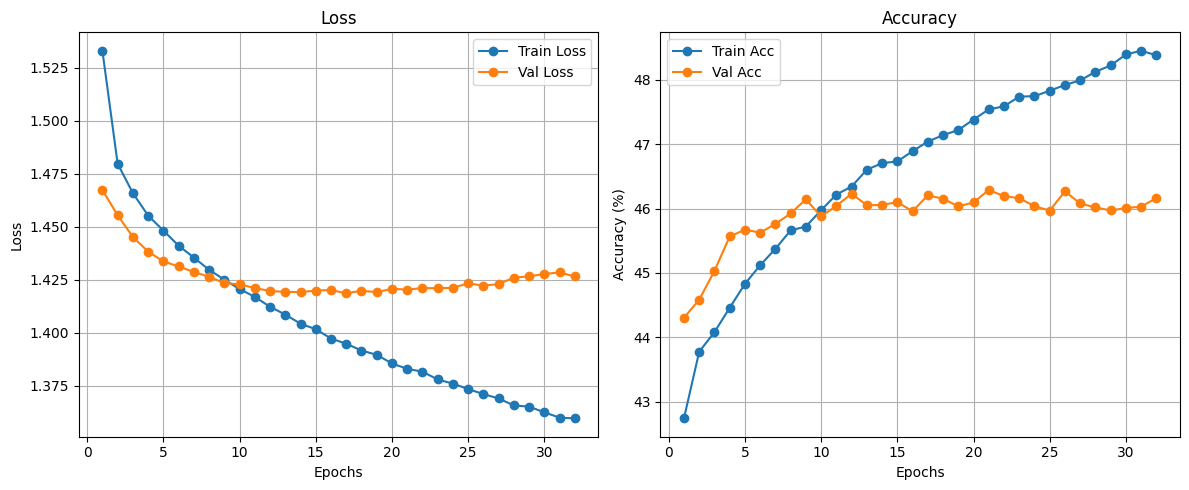


--- Predictions and Evaluation ---
Predicting on test set...

--- Model Evaluation ---
Test Accuracy: 0.4643

--- Classification Report ---
                          precision    recall  f1-score   support

AGG ASSAULT ON P/OFFICER       0.00      0.00      0.00         1
            AGGR ASSAULT       0.00      0.00      0.00        14
                 ASSAULT       0.35      0.31      0.33      9490
                 Assault       0.00      0.00      0.00        20
                BURGLARY       0.37      0.22      0.27      8684
     Breaking & Entering       0.00      0.00      0.00        14
 CRIM NEGLIGENT HOMICIDE       0.00      0.00      0.00        15
           LARCENY/THEFT       0.51      0.82      0.63     21080
            MANSLAUGHTER       0.00      0.00      0.00         3
                  MURDER       0.00      0.00      0.00       153
                    RAPE       0.00      0.00      0.00       433
                 ROBBERY       0.25      0.00      0.00      3062


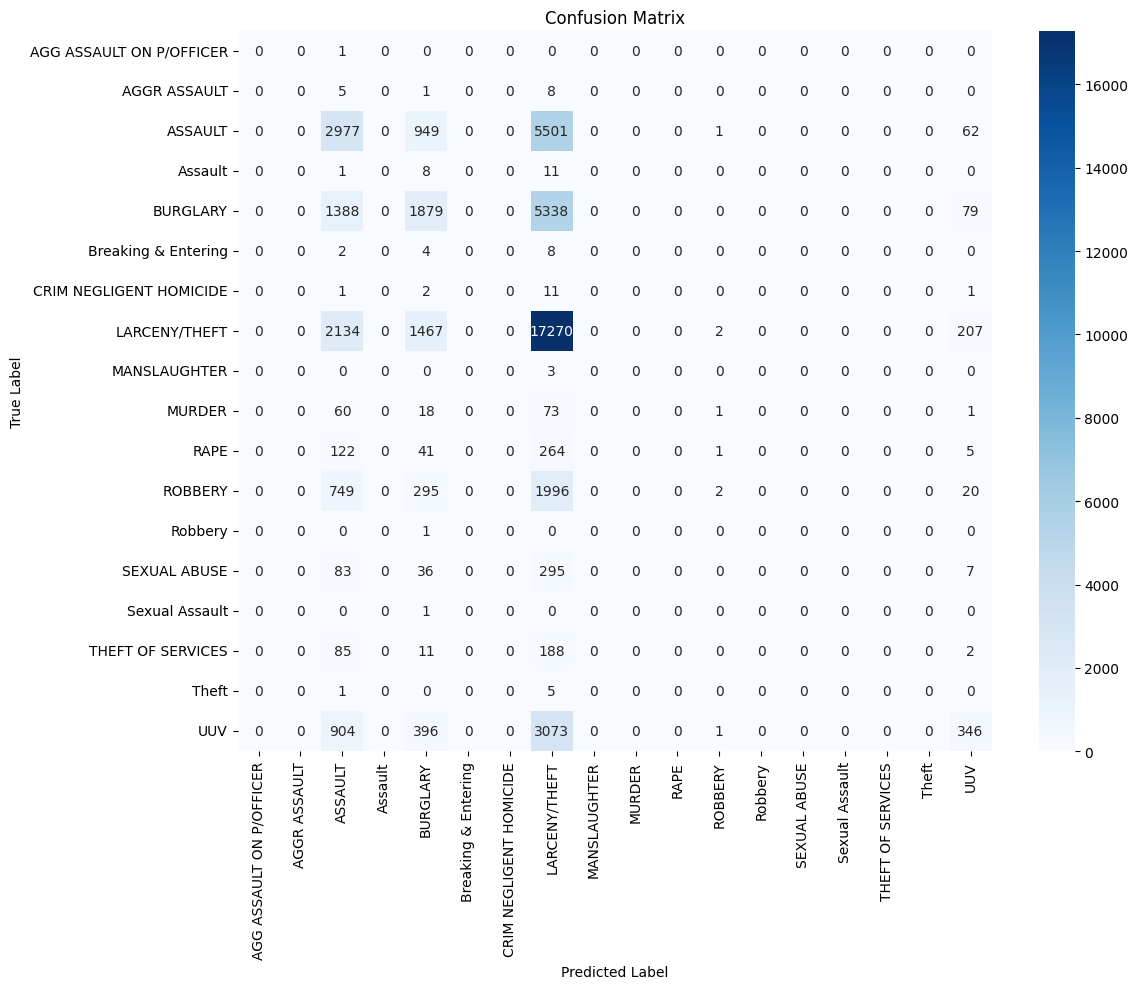

In [28]:

import matplotlib.pyplot as plt
import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import numpy as np
from torch.utils.data import DataLoader, TensorDataset # Added for DataLoader recreation if needed

print("Training History, Predictions, and Evaluation ")

print("\n--- Training History Visualization ---")
if 'train_losses' in globals() and 'val_losses' in globals() and \
   'train_accuracies' in globals() and 'val_accuracies' in globals():

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'o-', label='Train Loss')
    plt.plot(epochs, val_losses, 'o-', label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, [acc * 100 for acc in train_accuracies], 'o-', label='Train Acc')
    plt.plot(epochs, [acc * 100 for acc in val_accuracies], 'o-', label='Val Acc')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

else:
    print("Training history lists not found. Skipping plot.")


print("\n--- Predictions and Evaluation ---")


if 'model' not in globals():
    print("Error: 'model' not found. Cannot predict. Ensure Cell 11 ran successfully.")

    if 'train_dataloader' in locals(): del train_dataloader 
    if 'val_dataloader' in locals(): del val_dataloader
    if 'test_dataloader' in locals(): del test_dataloader
    print("Please ensure Cell 11 runs completely first.")




if 'test_dataloader' not in globals():

    print("Warning: 'test_dataloader' not found. Attempting to recreate from tensors.")
    if 'X_test_tensor' in globals() and 'y_test_tensor' in globals() and 'BATCH_SIZE' in globals():
        try:

            if X_test_tensor.shape[0] > 0 and y_test_tensor.shape[0] > 0:
                test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
        
                global test_dataloader
                test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
                print("Recreated 'test_dataloader' successfully.")
            else:
                print("Error: X_test_tensor or y_test_tensor is empty. Cannot create test_dataloader for evaluation.")
      
        except Exception as e:
            print(f"Error recreating test_dataloader: {e}. Cannot proceed with evaluation.")
     
    else:
        print("Error: Required tensors (X_test_tensor, y_test_tensor) or BATCH_SIZE not found. Cannot create test_dataloader for evaluation.")
   

if 'le' not in globals():
    print("Error: 'le' (LabelEncoder) not found. Cannot inverse transform labels. Ensure Cell 7 ran successfully.")


if 'model' in globals() and 'test_dataloader' in globals() and 'le' in globals():

    if 'device' not in globals():
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Device was not global, setting to: {device}")

    model.eval() 
    all_predictions = []
    all_true_labels = []

    print("Predicting on test set...")
    with torch.no_grad(): 
        for inputs, labels in test_dataloader:
            inputs = inputs.to(device) 
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1) 

            all_predictions.extend(predicted.cpu().numpy()) 
            all_true_labels.extend(labels.cpu().numpy())


    all_predictions_np = np.array(all_predictions).flatten()
    all_true_labels_np = np.array(all_true_labels).flatten()


    try:
        predicted_labels_original = le.inverse_transform(all_predictions_np)
        true_labels_original = le.inverse_transform(all_true_labels_np)
    except ValueError as e:
        print(f"Warning: Error during inverse_transform: {e}. This might happen if predicted labels are outside the range of trained labels.")
   
        known_classes = list(le.classes_)
        label_mapping = {idx: label for idx, label in enumerate(known_classes)}
        predicted_labels_original = [label_mapping.get(label_idx, 'UNKNOWN_PRED') for label_idx in all_predictions_np]
        true_labels_original = [label_mapping.get(label_idx, 'UNKNOWN_TRUE') for label_idx in all_true_labels_np]
        print("Proceeding with partial label mapping. Results might contain 'UNKNOWN' labels.")


    print("\n--- Model Evaluation ---")
    accuracy = accuracy_score(true_labels_original, predicted_labels_original)
    print(f"Test Accuracy: {accuracy:.4f}")

    print("\n--- Classification Report ---")

  
    unique_labels = np.unique(np.concatenate((true_labels_original, predicted_labels_original)))
    print(classification_report(true_labels_original, predicted_labels_original, labels=unique_labels, zero_division=0))

    print("\n--- Confusion Matrix ---")

    cm = confusion_matrix(true_labels_original, predicted_labels_original, labels=unique_labels)
    plt.figure(figsize=(12, 10)) 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=unique_labels, yticklabels=unique_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout() 
    plt.show()

else:
    print("Skipping prediction/evaluation as critical components are missing after attempting to recreate them.")